IRIS FLOWER DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Total number of samples: 150

Training samples: 120
Testing samples: 30

Feature scaling completed.

Perceptron model trained successfully!

PERCEPTRON IRIS CLASSIFICATION RESULTS

Accuracy: 90.0 %

Actual vs Predicted:
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: virginica 	Predicted: virginica
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual

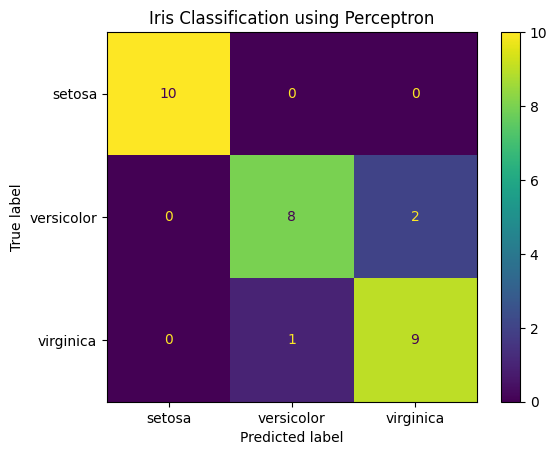


NEW FLOWER CLASSIFICATION

New Flower Details:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm

Predicted Flower Class:
setosa


In [ ]:
# Experiment: Perceptron Based Iris Classification
# Aim: Implement Iris flower classification using
#      the Perceptron algorithm.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("IRIS FLOWER DATASET")
print("=" * 60)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nTotal number of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ---------------------------------------------------------
# STEP 4: Create Perceptron classifier
# ---------------------------------------------------------

model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)


# ---------------------------------------------------------
# STEP 5: Train the Perceptron model
# ---------------------------------------------------------

model.fit(
    X_train_scaled,
    y_train
)

print("\nPerceptron model trained successfully!")


# ---------------------------------------------------------
# STEP 6: Predict the test data
# ---------------------------------------------------------

y_pred = model.predict(
    X_test_scaled
)


# ---------------------------------------------------------
# STEP 7: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("PERCEPTRON IRIS CLASSIFICATION RESULTS")
print("=" * 60)

print("\nAccuracy:",
      round(accuracy * 100, 2),
      "%")


# ---------------------------------------------------------
# STEP 8: Display actual vs predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(
    y_test,
    y_pred
):

    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 9: Classification Report
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# ---------------------------------------------------------
# STEP 10: Generate confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 11: Display confusion matrix graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title(
    "Iris Classification using Perceptron"
)

plt.show()


# ---------------------------------------------------------
# STEP 12: Classify a new flower
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])


# Scale the new flower using
# the same scaler used for training

new_flower_scaled = scaler.transform(
    new_flower
)


prediction = model.predict(
    new_flower_scaled
)


print("\n" + "=" * 60)
print("NEW FLOWER CLASSIFICATION")
print("=" * 60)

print("\nNew Flower Details:")

print("Sepal Length: 5.1 cm")
print("Sepal Width : 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width : 0.2 cm")

print("\nPredicted Flower Class:")

print(
    iris.target_names[prediction[0]]
)